In [6]:
#Importando as bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,export_graphviz

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [7]:
#Carregando a base de dados

base = pd.read_csv('Churn_Modelling.csv')

In [8]:
#Exibindo as primeiras linhas da base de dados

base.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
#Analisando a média e a mediana da idade dos clientes

print(np.mean(base['Age']))
print(np.median(base['Age']))


38.9218
37.0


In [10]:
#Visualizando as informações da base de dados

base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [11]:
#Selecionando as colunas que não serão utilizadas no modelo

lisdel = ['RowNumber','CustomerId','Surname']

In [12]:
#Removendo as colunas selecionadas

base = base.drop(columns=lisdel)

In [13]:
#Visualizando as estatísticas descritivas da base de dados

base.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<Axes: xlabel='Exited', ylabel='count'>

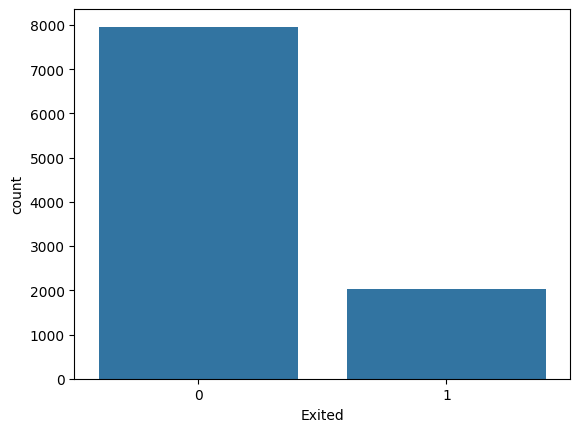

In [14]:
#Visualizando a distribuição da variável alvo

sns.countplot(x='Exited', data=base)

<Axes: xlabel='Exited', ylabel='Age'>

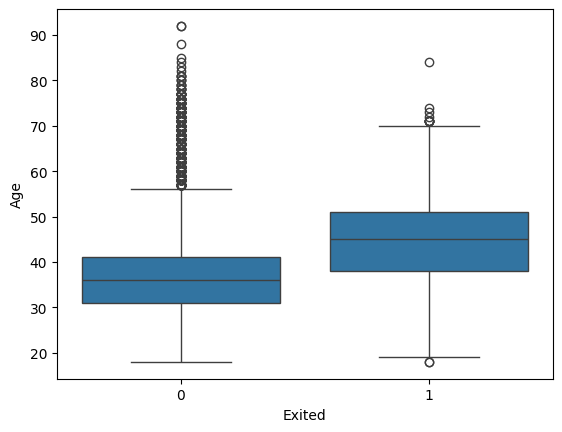

In [15]:
#Visualizando a relação entre a idade dos clientes e a variável alvo

sns.boxplot(x='Exited', y='Age', data=base)

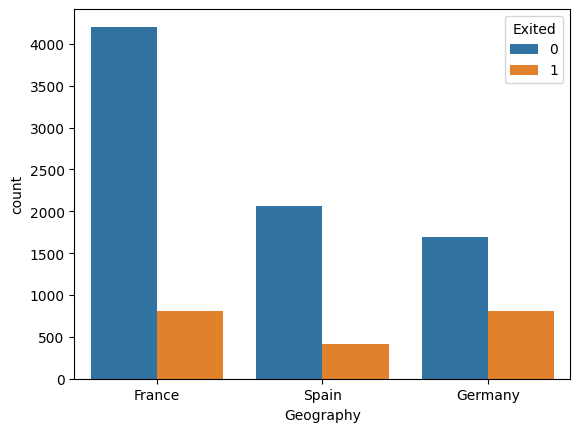

In [16]:
#Visualizando a relação entre a variável 'Geography' e a variável alvo

sns.countplot(
    x='Geography',
    hue='Exited',
    data=base
)
plt.show()

In [17]:
#Criando um codificador para a variável Genero - Serão somente 0 e 1


le = LabelEncoder()
base['Gender'] = le.fit_transform(base['Gender'])

In [18]:
#Criando variáveis dummies para a variável 'Geography' e removendo a primeira coluna para evitar a multicolinearidade

base = pd.get_dummies(base, columns=['Geography'], drop_first=True)

In [19]:
#Porcentagem de clientes que saíram do banco

base['Exited'].value_counts() / len(base) * 100


Exited
0    79.63
1    20.37
Name: count, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

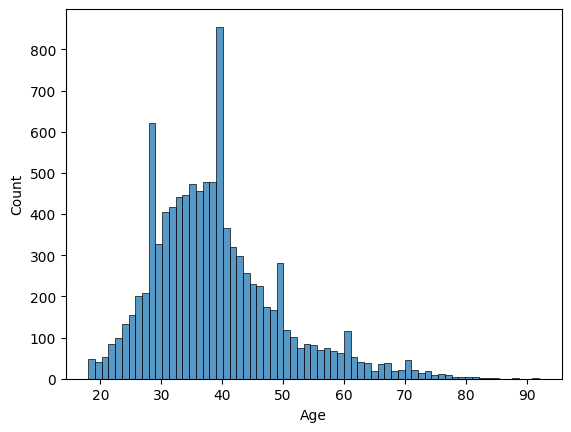

In [20]:
#Histograma da idade dos clientes

sns.histplot(base['Age'])

<Axes: xlabel='CreditScore', ylabel='Count'>

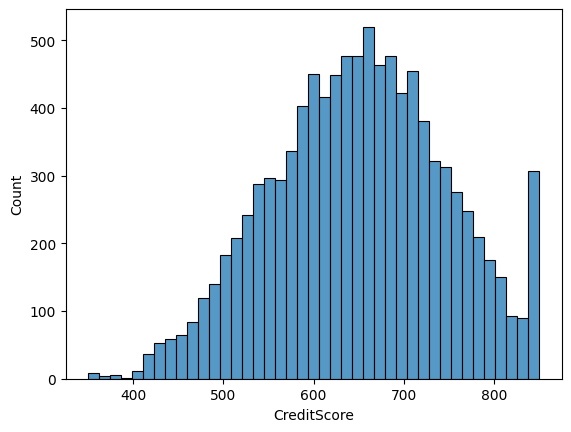

In [21]:
#Histograma do score dos clientes

sns.histplot(base['CreditScore'])

<Axes: xlabel='Exited', ylabel='CreditScore'>

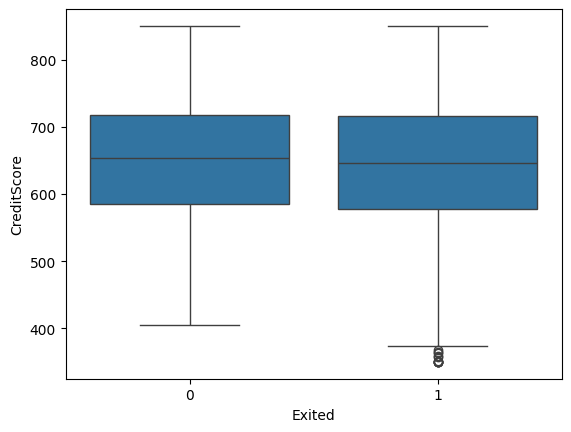

In [22]:
sns.boxplot(x='Exited', y='CreditScore', data=base)

<Axes: xlabel='Exited', ylabel='IsActiveMember'>

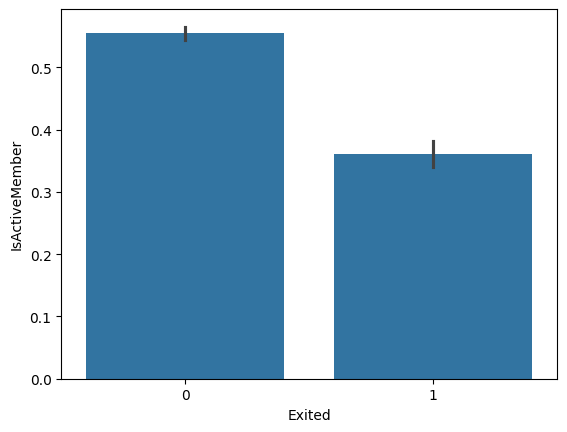

In [23]:
sns.barplot(x='Exited', y='IsActiveMember', data=base)

In [24]:
#Separando a base entre treino e teste

X = base.drop(columns=['Exited'])
y = base['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
#Padronizando os dados utilizando o MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

cols = X_train.columns
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=cols)

In [26]:
#Exibindo os dados de treino padronizados

X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,0.538,0.0,0.189189,0.4,0.699113,0.333333,1.0,1.0,0.864027,0.0,1.0
1,0.586,0.0,0.216216,0.7,0.639407,0.000000,0.0,1.0,0.942778,1.0,0.0
2,0.422,1.0,0.202703,0.6,0.000000,0.333333,0.0,0.0,0.868470,0.0,0.0
3,0.536,1.0,0.310811,0.8,0.150271,0.000000,1.0,1.0,0.979011,1.0,0.0
4,0.728,1.0,0.256757,0.9,0.591742,0.333333,0.0,1.0,0.756406,0.0,0.0


In [27]:
#Criando modelo de classificação utilizando arvores de decisão


classif_tree = DecisionTreeClassifier(
    criterion='entropy',         # Mede a impureza dos nós
    max_depth=5,              # Limita o crescimento para evitar "decorar" o treino
    min_samples_split=50,     # Mínimo de amostras para gerar uma nova divisão
    min_samples_leaf=20,      # Mínimo de amostras que devem restar em cada folha
    class_weight='balanced',  # Compensa se houver poucos casos de churn (Exited=1)
    random_state=42           # Mantém os resultados consistentes ao executar novamente
)

classif_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [28]:
for feature,importancia in zip(X_train.columns,classif_tree.feature_importances_*100):
    print("{}:{}".format(feature, importancia))  

CreditScore:0.0
Gender:0.0
Age:43.51131025279508
Tenure:0.30966813833995455
Balance:11.28877297732221
NumOfProducts:33.63784297797499
HasCrCard:0.0
IsActiveMember:6.924359062673517
EstimatedSalary:0.0
Geography_Germany:4.328046590894241
Geography_Spain:0.0


In [29]:
# criando um dicionário com as variáveis mais importantes para o modelo treinado
dic = {'score':classif_tree.feature_importances_*100,'features':X_train.columns}
#criando um dataframe com os dados
df = pd.DataFrame(dic).sort_values('score',ascending=False)
df

,score,features
2,43.511310,Age
5,33.637843,NumOfProducts
4,11.288773,Balance
7,6.924359,IsActiveMember
9,4.328047,Geography_Germany
3,0.309668,Tenure
0,0.000000,CreditScore
1,0.000000,Gender
6,0.000000,HasCrCard
8,0.000000,EstimatedSalary


In [30]:
#Testando o modelo com os dados de teste

y_pred_tree = classif_tree.predict(X_test)

c:\Users\renovaci\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [31]:
y_pred_tree

array([0, 0, 0, ..., 1, 0, 1], shape=(3000,))

In [32]:
confusion_matrix_tree = confusion_matrix(y_true=y_test, y_pred=y_pred_tree, labels=classif_tree.classes_) 
confusion_matrix_tree

array([[1700,  716],
       [ 122,  462]])

In [33]:
#classification_report:

print(classification_report(y_test, y_pred_tree))

# Resultado do classification_report:

              precision    recall  f1-score   support

           0       0.93      0.70      0.80      2416
           1       0.39      0.79      0.52       584

    accuracy                           0.72      3000
   macro avg       0.66      0.75      0.66      3000
weighted avg       0.83      0.72      0.75      3000



In [34]:
#Testando modelo de regressão logistica


logreg = LogisticRegression(penalty='l2',random_state=17)

In [37]:
#Treinando o modelo de regressão logística com os dados de treino

logistica = logreg.fit(X_train, y_train)  #fitting the model 

In [38]:
# Os coeficientes do modelo (b1,b2,b3....)

coefficients = pd.concat([pd.DataFrame(cols),pd.DataFrame(np.transpose(logistica.coef_))], axis = 1)
coefficients

,0,0
0,CreditScore,-0.380443
1,Gender,-0.528568
2,Age,5.014055
3,Tenure,-0.211965
4,Balance,0.672148
5,NumOfProducts,-0.231021
6,HasCrCard,-0.065385
7,IsActiveMember,-1.024188
8,EstimatedSalary,0.016180
9,Geography_Germany,0.767974


In [39]:
#Fazendo a previsão com os dados de teste


y_pred_log = logistica.predict(X_test)

c:\Users\renovaci\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
#Acurácia do modelo de regressão logística com os dados de teste


logistica.score(X_test, y_test)

c:\Users\renovaci\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8133333333333334

In [41]:
#Realizando a matriz de confusão para o modelo de regressão logística


confusion_matrix_log = confusion_matrix(y_test, y_pred_log)
confusion_matrix_log

array([[2328,   88],
       [ 472,  112]])

In [ ]:
#Visualizando o classification_report para o modelo de regressão logística


print(classification_report(y_test, logistica.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      2416
           1       0.56      0.19      0.29       584

    accuracy                           0.81      3000
   macro avg       0.70      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



c:\Users\renovaci\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
#  Conclusão

# O objetivo deste projeto foi desenvolver um modelo capaz de prever a evasão de clientes (Churn) em uma instituição bancária, utilizando técnicas de análise de dados e Machine Learning.

# Inicialmente, foi realizada uma análise exploratória dos dados para compreender as características dos clientes e identificar possíveis fatores relacionados ao cancelamento de contas. Durante essa etapa, observou-se que variáveis como idade, saldo da conta, país de residência e status de atividade do cliente apresentam relação com a probabilidade de churn.

# Após o pré-processamento dos dados, incluindo a codificação das variáveis categóricas e a padronização das variáveis numéricas, foram treinados modelos de classificação para prever a saída dos clientes. Os modelos foram avaliados por meio de métricas como acurácia, matriz de confusão e relatório de classificação.

# Os resultados demonstraram que é possível identificar padrões comportamentais associados ao churn, permitindo que a instituição financeira adote estratégias preventivas para retenção de clientes. Além disso, a análise evidenciou a importância de fatores como idade e nível de engajamento do cliente para a previsão do cancelamento.